# Exploratory Data Analysis — Jigsaw Toxic Comment Classification

**Course context:** CMPE258 — Kaggle [Jigsaw Toxic Comment Classification Challenge](https://www.kaggle.com/c/jigsaw-toxic-comment-classification-challenge)

This notebook lives in **`eda/`**; the code cell below resolves paths to the repository **`data/train.csv`** (whether you launch Jupyter from the repo root or from `eda/`).

This notebook analyzes the official **training split** (**159,571** Wikipedia talk-page comments). We check data quality, quantify **multi-label** toxicity (about **90%** of rows have no positive label; about **10%** have at least one), measure **class imbalance** across the six heads (down to **~0.3%** prevalence for `threat`), inspect **label co-occurrence**, and relate **comment length** and a small **unigram** sketch to modeling choices.

**Note:** Example comments below may contain offensive language present in the dataset.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer


def _project_root() -> Path:
    """Repo root (directory containing `data/`), whether cwd is project root or `eda/`."""
    here = Path.cwd().resolve()
    for p in (here, *here.parents):
        if (p / "data").is_dir():
            return p
    return here


DATA_DIR = _project_root() / "data"
TRAIN_PATH = DATA_DIR / "train.csv"

LABEL_COLS = [
    "toxic",
    "severe_toxic",
    "obscene",
    "threat",
    "insult",
    "identity_hate",
]

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_colwidth", 120)


## 1. Load data and schema

The competition **`train.csv`** used in this notebook has **159,571** rows and **8** columns: `id`, `comment_text`, and six binary toxicity indicators. The `df.info()` summary below matches a complete local download (non-null counts equal to the row count).

In [2]:
if not TRAIN_PATH.exists():
    raise FileNotFoundError(
        f"Missing {TRAIN_PATH}. Download competition CSVs from Kaggle into data/ (see README)."
    )

df = pd.read_csv(TRAIN_PATH)
df.head()


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,"Explanation\r\nWhy the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, j...",0,0,0,0,0,0
1,000103f0d9cfb60f,"D'aww! He matches this background colour I'm seemingly stuck with. Thanks. (talk) 21:51, January 11, 2016 (UTC)",0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It's just that this guy is constantly removing relevant information and ...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\r\nMore\r\nI can't make any real suggestions on improvement - I wondered if the section statistics should be later...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember what page that's on?",0,0,0,0,0,0


In [3]:
print("Shape (rows, columns):", df.shape)
print()
df.info()


Shape (rows, columns): (159571, 8)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id             159571 non-null  object
 1   comment_text   159571 non-null  object
 2   toxic          159571 non-null  int64 
 3   severe_toxic   159571 non-null  int64 
 4   obscene        159571 non-null  int64 
 5   threat         159571 non-null  int64 
 6   insult         159571 non-null  int64 
 7   identity_hate  159571 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 9.7+ MB


In [4]:
# Column dtypes and quick uniqueness
summary = pd.DataFrame(
    {
        "dtype": df.dtypes.astype(str),
        "non_null": df.notna().sum(),
        "n_unique": df.nunique(),
    }
)
summary


,dtype,non_null,n_unique
id,object,159571,159571
comment_text,object,159571,159571
toxic,int64,159571,2
severe_toxic,int64,159571,2
obscene,int64,159571,2
threat,int64,159571,2
insult,int64,159571,2
identity_hate,int64,159571,2


### 1.1 Data quality checks

We expect one row per comment `id`, non-null `comment_text`, and binary (0/1) label columns.

**Result (this run):** all **159,571** rows have non-null `comment_text`, **no duplicate `id`**, and no empty strings; label columns contain only **0** and **1**. The frame is analysis-ready without imputation for missing text.

In [5]:
dup_ids = df["id"].duplicated().sum()
empty_text = (df["comment_text"].fillna("").str.len() == 0).sum()
missing_text = df['comment_text'].isna().sum()

print(f"Duplicate ids: {dup_ids}")
print(f"Empty comment_text: {empty_text}")
print(f"Missing comment_text: {missing_text}")

for c in LABEL_COLS:
    bad = ~df[c].isin([0, 1])
    if bad.any():
        print(f"Non-binary values in {c}: {bad.sum()}")


Duplicate ids: 0
Empty comment_text: 0
Missing comment_text: 0


## 2. Label distribution (single-label and multi-label)

**Head prevalence (independent binary columns):** `toxic` is the most common positive label (**~9.6%** of rows), followed by `obscene` (**~5.3%**) and `insult` (**~4.9%**). `severe_toxic` appears in **~1.0%**, `identity_hate` in **~0.88%**, and `threat` is the rarest at **~0.30%** (only **478** positives). These rates are *not* mutually exclusive—one comment can activate several heads.

**Multi-label counts:** most rows have **zero** labels; among toxic rows, many have **one** positive head, but **thousands** carry **two or more**, and a handful carry up to **all six** (see the bar chart and value counts below). That pattern motivates per-label metrics and multi-output models rather than a single mutually exclusive class.

,count,prevalence
toxic,15294,0.095844
obscene,8449,0.052948
insult,7877,0.049364
severe_toxic,1595,0.009996
identity_hate,1405,0.008805
threat,478,0.002996


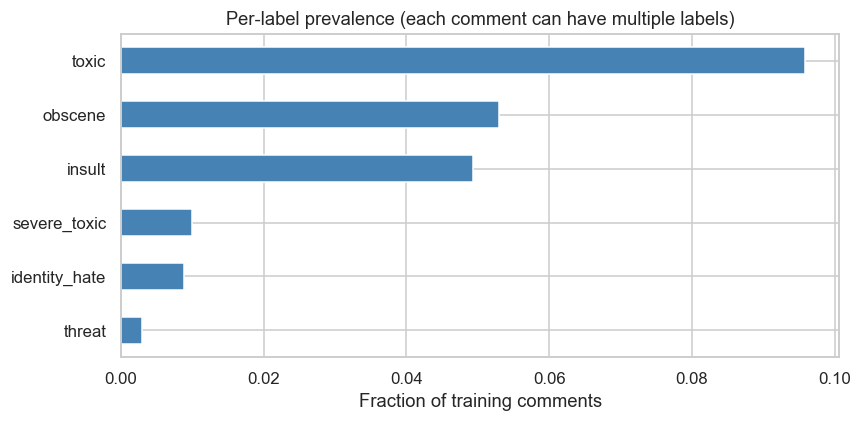

In [6]:
label_rates = df[LABEL_COLS].mean().sort_values(ascending=False)
label_counts = df[LABEL_COLS].sum().sort_values(ascending=False)

display(pd.DataFrame({"count": label_counts, "prevalence": label_rates}))

fig, ax = plt.subplots(figsize=(8, 4))
label_rates.plot(kind="barh", color="steelblue", ax=ax)
ax.set_xlabel("Fraction of training comments")
ax.set_title("Per-label prevalence (each comment can have multiple labels)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


In [7]:
# How many labels are active per comment?
print(f"How many labels (out of the labels {LABEL_COLS}) are active per comment:")
n_labels = df[LABEL_COLS].sum(axis=1)
n_labels.value_counts().sort_index()


How many labels (out of the labels ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']) are active per comment:


0    143346
1      6360
2      3480
3      4209
4      1760
5       385
6        31
Name: count, dtype: int64

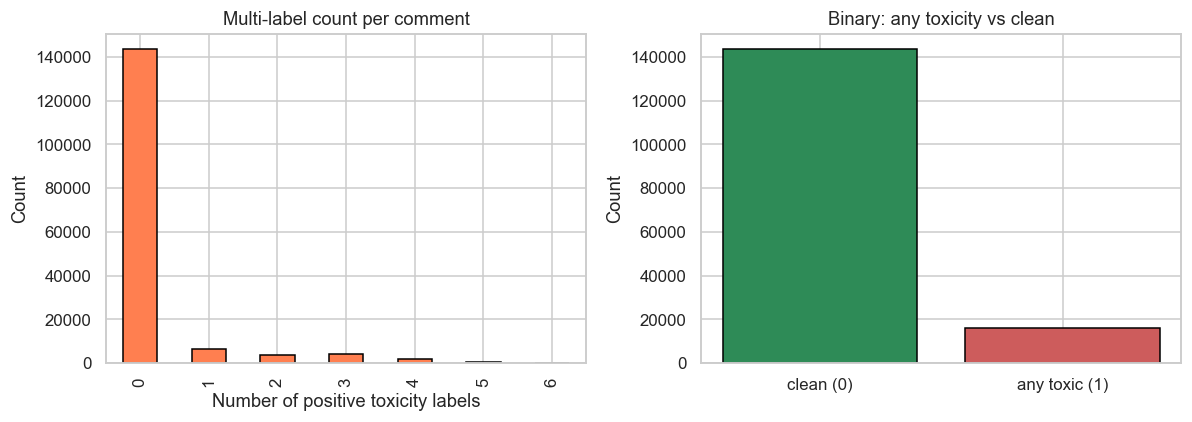

Clean comments: 143,346 (89.83%)
At least one toxic label: 16,225 (10.17%)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

n_labels.value_counts().sort_index().plot(kind="bar", ax=axes[0], color="coral", edgecolor="black")
axes[0].set_xlabel("Number of positive toxicity labels")
axes[0].set_ylabel("Count")
axes[0].set_title("Multi-label count per comment")

any_toxic = (n_labels > 0).astype(int)
axes[1].bar(["clean (0)", "any toxic (1)"], any_toxic.value_counts().reindex([0, 1]).values, color=["seagreen", "indianred"], edgecolor="black")
axes[1].set_ylabel("Count")
axes[1].set_title("Binary: any toxicity vs clean")
plt.tight_layout()
plt.show()

print(f"Clean comments: {(n_labels == 0).sum():,} ({(n_labels == 0).mean():.2%})")
print(f"At least one toxic label: {(n_labels > 0).sum():,} ({(n_labels > 0).mean():.2%})")


### 2.1 Co-occurrence and correlation

Toxicity types are **not mutually exclusive**. The Pearson matrix below shows a tight cluster among **`toxic`–`obscene`–`insult`** (pairwise correlations roughly **0.65–0.74** in this train set): those labels tend to fire together. **`severe_toxic`** correlates moderately with **`toxic`** (~**0.31**) and less strongly with the others. **`threat`** is comparatively **weakly** correlated with every other head (~**0.12–0.16**), so a model that does well on general toxicity may still **miss threats** unless that head is evaluated explicitly.

The row-conditioned heatmap (“given label *A*, how often is *B* also 1?”) makes overlap concrete—for example, among `obscene` comments, other insult-related flags are very common.

**Hierarchy check:** in this training file, **every** `severe_toxic` comment also has `toxic` = 1 (**0** rows with `severe_toxic` alone). That is a strict subset relationship *on train*; it still justifies treating `severe_toxic` as a rarer, nested phenomenon in modeling and metrics.

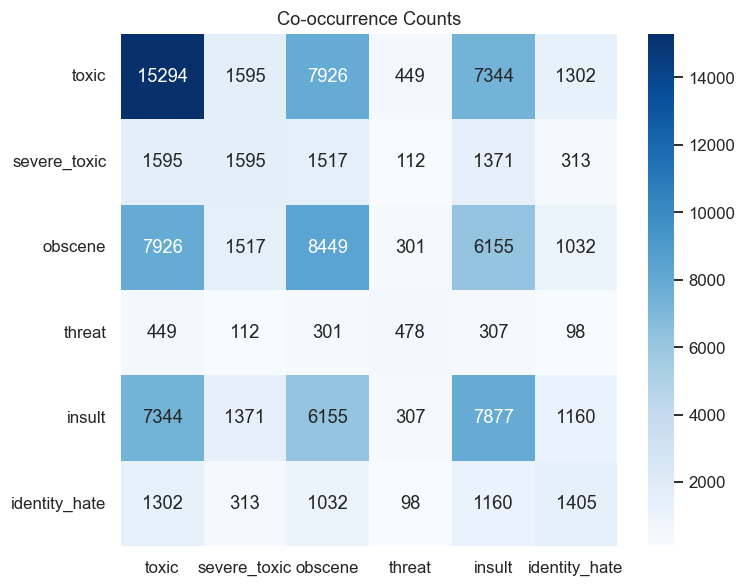

In [27]:
co_occurrence = df[LABEL_COLS].T.dot(df[LABEL_COLS])

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(co_occurrence, annot=True, fmt="d", cmap="Blues")
ax.set_title("Co-occurrence Counts")
plt.tight_layout()
plt.show()

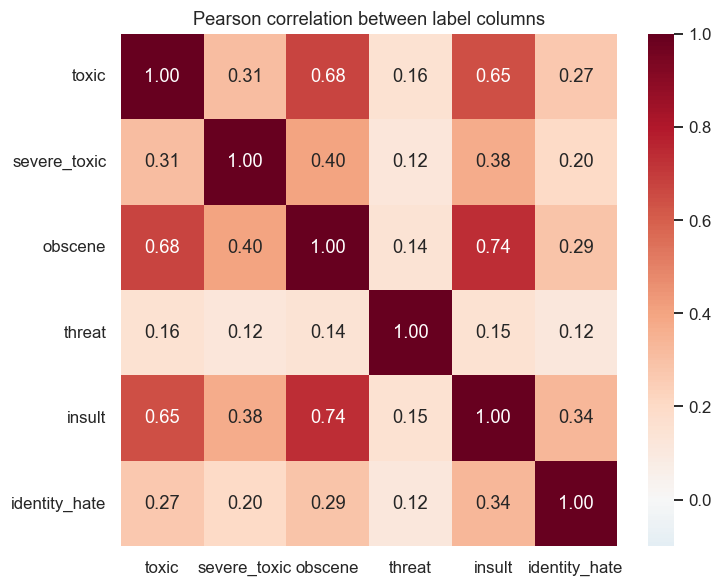

In [10]:
corr = df[LABEL_COLS].corr()
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-0.1, vmax=1, ax=ax)
ax.set_title("Pearson correlation between label columns")
plt.tight_layout()
plt.show()


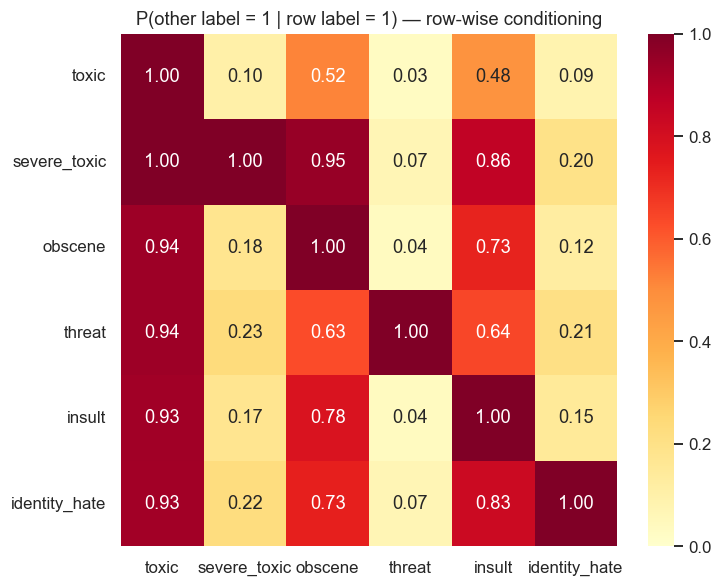

In [11]:
# Conditional probability P(B | A) for rare pairs (symmetric display)
co = pd.DataFrame(index=LABEL_COLS, columns=LABEL_COLS, dtype=float)
for a in LABEL_COLS:
    mask_a = df[a] == 1
    if mask_a.sum() == 0:
        continue
    co.loc[a, :] = df.loc[mask_a, LABEL_COLS].mean().values

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(co.astype(float), annot=True, fmt=".2f", cmap="YlOrRd", vmin=0, vmax=1, ax=ax)
ax.set_title("P(other label = 1 | row label = 1) — row-wise conditioning")
plt.tight_layout()
plt.show()


In [12]:
# On this train CSV, severe_toxic rows are a subset of toxic (see printed counts)
both = ((df["toxic"] == 1) & (df["severe_toxic"] == 1)).sum()
severe_only = ((df["toxic"] == 0) & (df["severe_toxic"] == 1)).sum()
print(f"severe_toxic AND toxic: {both:,}")
print(f"severe_toxic but NOT toxic: {severe_only:,}")


severe_toxic AND toxic: 1,595
severe_toxic but NOT toxic: 0


### 2.2 Analysis of Toxicity Rows where `toxic`==0

As can be seen above in the row-wise conditioning heatmap, not all rows with a toxic label (`insult`, `threat`, etc.) have a positive label for the `toxic` column. For instance, in the training dataset, given that a comment was labeled as `identity_hate`, only about 93% of those comments had a positivie label for `toxic`. In other words, `identity_hate` is not a strict subset of `toxic`, which seems unintuitive. While this edge case could be a result of human labeling error, it is also possible that this distinction was drawn purposefully. To determine this, we will analyze all rows that contain at least one toxicity lablel, but no rows where the `toxic` column has a positive label.

In [56]:
# Rows with at least one positive label on a non-`toxic` head, but `toxic` itself is 0
non_toxic_head_cols = ["severe_toxic", "obscene", "threat", "insult", "identity_hate"]
toxic_var_df = df[(df["toxic"] == 0) & (df[non_toxic_head_cols].eq(1).any(axis=1))]

og_df_size = len(df)
sub_size = len(toxic_var_df)

print(f"Size of Subset: {sub_size}")
print(f"Size of Original Data: {og_df_size}")
print(f"Percentage of Rows in Subset compared to Original Data: {100*sub_size/og_df_size:.3f}%")
display(toxic_var_df[non_toxic_head_cols].drop(columns="severe_toxic").value_counts())

Size of Subset: 931
Size of Original Data: 159571
Percentage of Rows in Subset compared to Original Data: 0.583%


obscene  threat  insult  identity_hate
1        0       0       0                317
0        0       1       0                301
1        0       1       0                181
0        0       0       1                 54
                 1       1                 28
         1       0       0                 22
1        0       1       1                 18
                 0       1                  3
0        1       1       0                  3
1        1       0       0                  2
                 1       0                  2
Name: count, dtype: int64

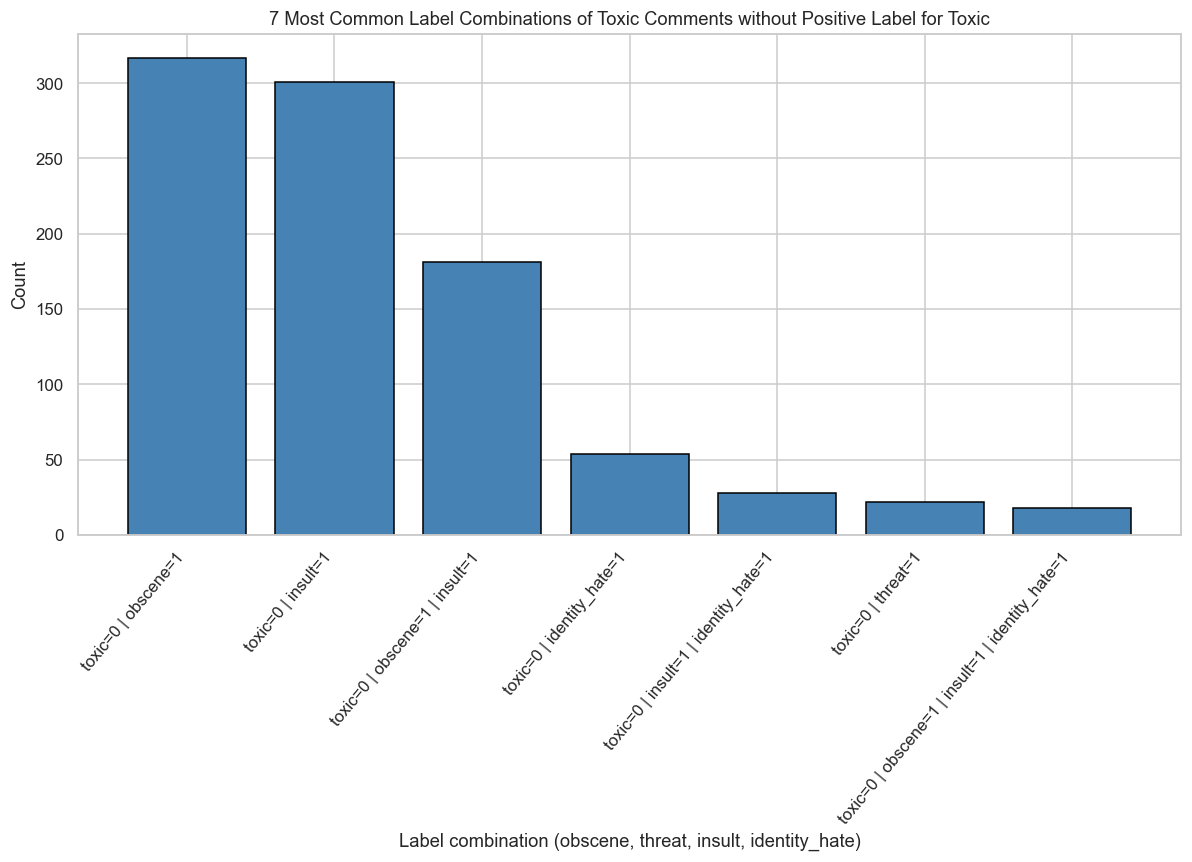

In [51]:
# Bar chart: 4-bit patterns (obscene, threat, insult, identity_hate) for toxic=0 rows with some other head positive
# Excludes the `severe_toxic` column from the pattern, matching value_counts on the four columns only.
sub = toxic_var_df[non_toxic_head_cols].drop(columns="severe_toxic")
combo_counts = sub.value_counts().sort_values(ascending=False)

patterns_df = combo_counts.index.to_frame(index=False)
x_labels = [ "toxic=0 | " + 
    " | ".join(f"{c}={int(row[c])}" for c in sub.columns if row[c] == 1)
    for _, row in patterns_df.iterrows()
]

LIMIT = 7

fig, ax = plt.subplots(figsize=(11, 8))
ax.bar(x_labels[:LIMIT], combo_counts.values[:LIMIT], color="steelblue", edgecolor="black")
ax.set_ylabel("Count")
ax.set_xlabel("Label combination (obscene, threat, insult, identity_hate)")
ax.set_title(f"{LIMIT} Most Common Label Combinations of Toxic Comments without Positive Label for Toxic")
plt.xticks(rotation=50, ha="right")
plt.tight_layout()
plt.show()

c:\Users\cghae\SJSU\CMPE 258\SemesterProject\cmpe258-2026Fall-ToxicCommentDetection\.venv\Lib\site-packages\upsetplot\plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
c:\Users\cghae\SJSU\CMPE 258\SemesterProject\cmpe258-2026Fall-ToxicCommentDetection\.venv\Lib\site-packages\upsetplot\plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. Th

<Figure size 1540x880 with 0 Axes>

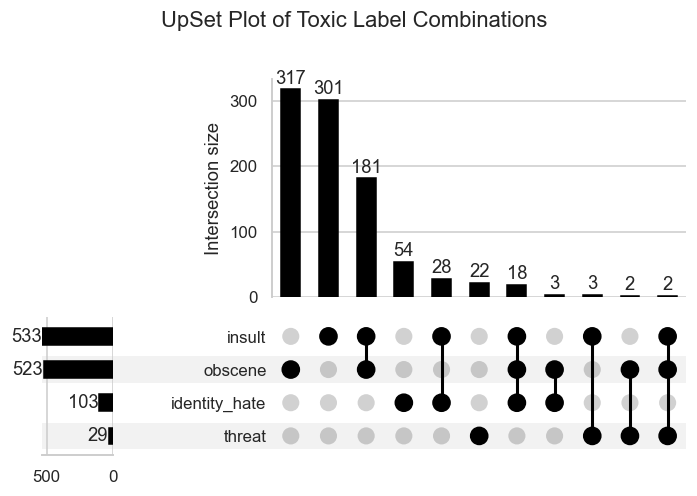

In [68]:
# Upset Plot
from upsetplot import UpSet, from_indicators

# Columns to include in the UpSet plot
upset_cols = ["identity_hate", "threat", "insult", "obscene"]

# Make sure these columns are boolean
upset_df = toxic_var_df[upset_cols].astype(bool)

# Convert to UpSet-compatible format
upset_data = from_indicators(upset_cols, upset_df)

# Plot
plt.figure(figsize=(14, 8))
upset = UpSet(
    upset_data,
    subset_size="count",
    show_counts=True,
    sort_by="cardinality",
    sort_categories_by="-cardinality"
)
upset.plot()
plt.suptitle("UpSet Plot of Toxic Label Combinations", y=1.02)
plt.show()


In [ ]:
# Show Distribution of Labels in this subset compared to original DataFrame
# i.e., percentage of threats, percentage of obscene, etc.


Percentage of Rows in Subset compared to Original Data: 0.583%


In [16]:
# Co-occurence

In [17]:
# Correlation

In [18]:
# Show samples from each of the 5 categories and possibly one that is all 5 but not toxic (if applicable)

In [19]:
# UpSet Plot (look into this)

## 3. Text statistics

Comments are **right-skewed** in length: median length is about **205** characters and **36** whitespace-separated tokens, while the mean is much higher (**~394** chars, **~67** words) because of a long tail. The **99th percentile** reaches about **3.4k** characters (**~567** tokens), and the maximum allowed length in the export caps around **5k** characters—so truncation or max-length choices matter for RNNs and transformers.

The **clean vs any-toxic** KDE compares distributions after clipping each side at its **99th percentile**. If you see `RuntimeWarning` messages from SciPy during KDE, they are numerical noise from the density estimator and do not invalidate the qualitative comparison.

In [20]:
# Character and word counts (split on whitespace — rough proxy)
text = df["comment_text"].fillna("")

df = df.assign(
    char_len=text.str.len(),
    word_len=text.str.split().str.len(),
)

df[["char_len", "word_len"]].describe(percentiles=[0.5, 0.9, 0.95, 0.99])


,char_len,word_len
count,159571.000000,159571.000000
mean,396.593961,67.273527
std,594.387869,99.230702
min,6.000000,1.000000
50%,207.000000,36.000000
90%,895.000000,152.000000
95%,1364.000000,230.000000
99%,3471.300000,567.000000
max,5000.000000,1411.000000


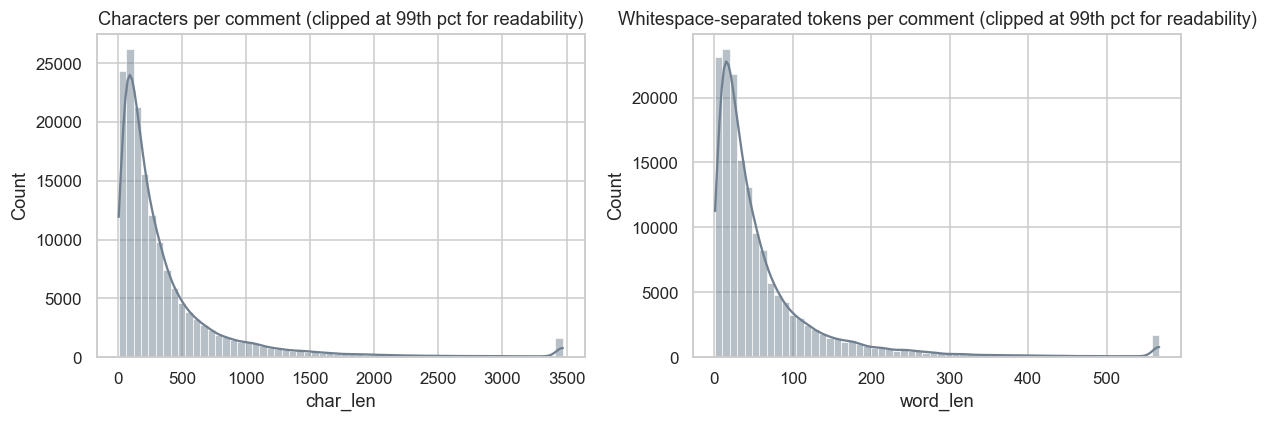

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, col, title in zip(
    axes,
    ["char_len", "word_len"],
    ["Characters per comment", "Whitespace-separated tokens per comment"],
):
    sns.histplot(df[col].clip(upper=df[col].quantile(0.99)), bins=60, kde=True, ax=ax, color="slategray")
    ax.set_title(f"{title} (clipped at 99th pct for readability)")
plt.tight_layout()
plt.show()


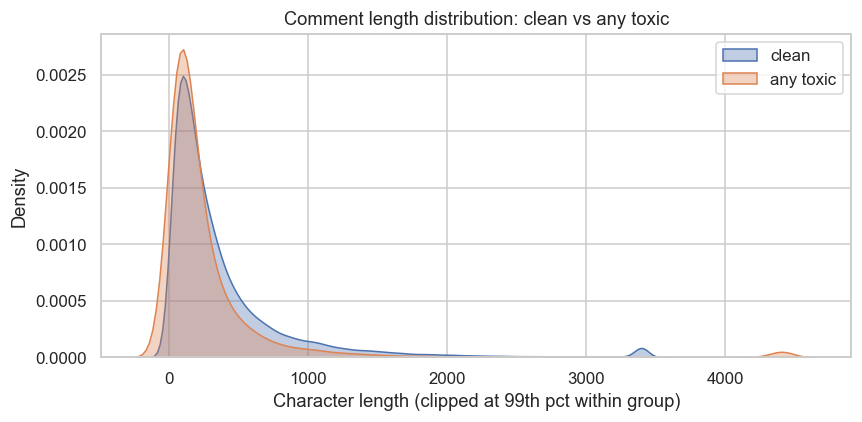

In [22]:
# Length vs any-toxicity (distributional shift is common in text classification)
clean = df.loc[n_labels == 0, "char_len"]
toxic = df.loc[n_labels > 0, "char_len"]

fig, ax = plt.subplots(figsize=(8, 4))
sns.kdeplot(clean.clip(upper=clean.quantile(0.99)), label="clean", ax=ax, fill=True, alpha=0.35)
sns.kdeplot(toxic.clip(upper=toxic.quantile(0.99)), label="any toxic", ax=ax, fill=True, alpha=0.35)
ax.set_xlabel("Character length (clipped at 99th pct within group)")
ax.set_title("Comment length distribution: clean vs any toxic")
ax.legend()
plt.tight_layout()
plt.show()


### 3.1 Memory footprint and length by label

With `object` columns materialized in pandas, the full training frame uses on the order of **~115 MB** with `memory_usage(deep=True)` (exact value depends on platform).

**Median length pattern:** for **every** toxicity head in the table above, **positive** examples are **shorter** at the median (roughly **94–123** characters) than **negative** examples (about **206–216** characters). So “toxic” rows are not longer rants on average—they are often **more compact** than typical clean talk-page text. That makes **length a risky standalone feature** (it can invert by slice) and supports checking models on length-stratified slices.

Approx. DataFrame memory (deep=True): 115.3 MB


,label,n_positive,median_chars | label=1,median_chars | label=0
0,toxic,15294,125.0,218.0
1,severe_toxic,1595,96.0,208.0
2,obscene,8449,112.0,214.0
3,threat,478,122.0,207.0
4,insult,7877,113.0,213.0
5,identity_hate,1405,115.0,208.0


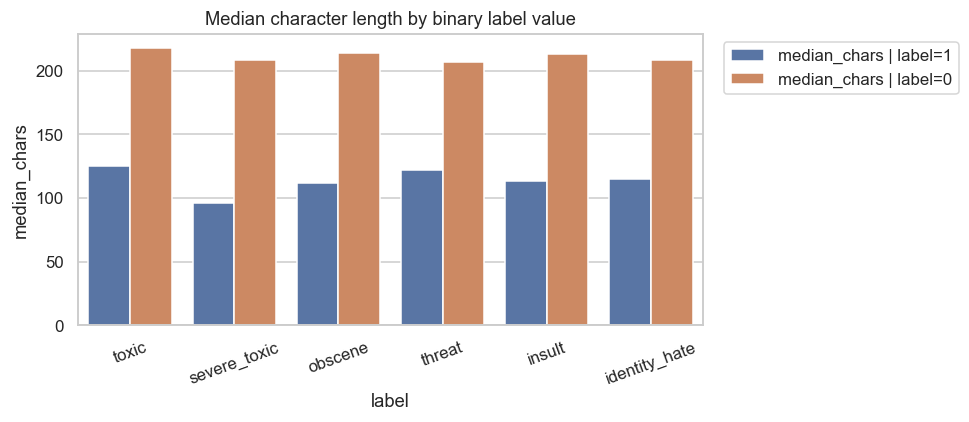

In [23]:
mem_mb = df.memory_usage(deep=True).sum() / 1e6
print(f"Approx. DataFrame memory (deep=True): {mem_mb:,.1f} MB")

rows = []
for c in LABEL_COLS:
    pos = df.loc[df[c] == 1, "char_len"]
    neg = df.loc[df[c] == 0, "char_len"]
    rows.append(
        {
            "label": c,
            "n_positive": int(len(pos)),
            "median_chars | label=1": float(pos.median()),
            "median_chars | label=0": float(neg.median()),
        }
    )
len_by_label = pd.DataFrame(rows)
display(len_by_label)

plot_df = len_by_label.melt(
    id_vars=["label"],
    value_vars=["median_chars | label=1", "median_chars | label=0"],
    var_name="subset",
    value_name="median_chars",
)
fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(data=plot_df, x="label", y="median_chars", hue="subset", ax=ax)
ax.set_title("Median character length by binary label value")
ax.tick_params(axis="x", rotation=20)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 4. Lexical sketch — frequent unigrams

A lightweight **bag-of-words** view (no stemming) highlights tokens that dominate each slice. For speed we fit `CountVectorizer` on a **random subsample of 80,000** rows (or the full training set if it is smaller), with `max_features=15_000` and `min_df=5`. The three panels contrast global frequencies vs clean-only vs any-toxic rows **within that sample**—use them as a qualitative guide, not a vocabulary for production without proper train/validation splitting.

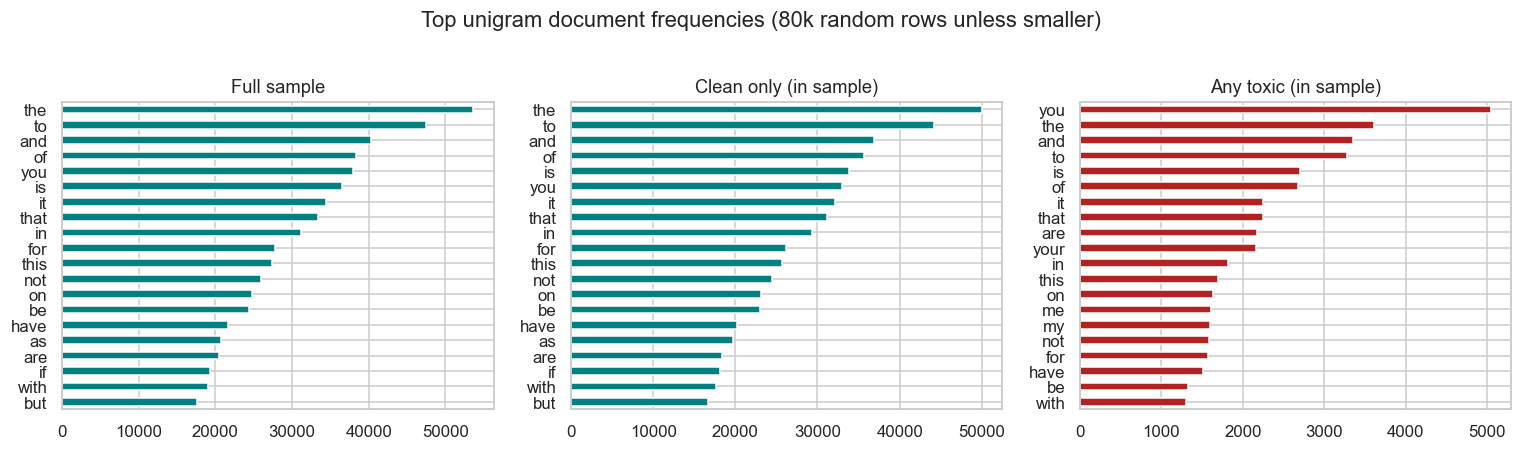

In [24]:
RNG = np.random.default_rng(42)
sample_n = min(80_000, len(df))
idx = RNG.choice(len(df), size=sample_n, replace=False)
sample = df.iloc[idx]

def top_unigrams(corpus, n=20, max_features=15_000):
    vec = CountVectorizer(max_features=max_features, binary=True, min_df=5)
    X = vec.fit_transform(corpus)
    freqs = np.asarray(X.sum(axis=0)).ravel()
    terms = np.array(vec.get_feature_names_out())
    order = np.argsort(-freqs)[:n]
    return pd.Series(freqs[order], index=terms[order])

corp_all = sample["comment_text"].fillna("").astype(str)
corp_toxic = sample.loc[sample[LABEL_COLS].sum(axis=1) > 0, "comment_text"].fillna("").astype(str)
corp_clean = sample.loc[sample[LABEL_COLS].sum(axis=1) == 0, "comment_text"].fillna("").astype(str)

top_all = top_unigrams(corp_all)
top_toxic = top_unigrams(corp_toxic)
top_clean = top_unigrams(corp_clean)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, series, title in zip(
    axes,
    [top_all, top_clean, top_toxic],
    ["Full sample", "Clean only (in sample)", "Any toxic (in sample)"],
):
    series.iloc[::-1].plot(kind="barh", ax=ax, color="teal" if "toxic" not in title.lower() else "firebrick")
    ax.set_title(title)
plt.suptitle("Top unigram document frequencies (80k random rows unless smaller)", y=1.02)
plt.tight_layout()
plt.show()


## 5. Qualitative examples (stratified)

Random samples illustrate **class imbalance** and **multi-label** cases. Adjust `n` or seeds as needed.

In [25]:
def show_samples(mask, title, n=3):
    sub = df.loc[mask, ["comment_text"] + LABEL_COLS].sample(n=n, random_state=1)
    print(title)
    display(sub)

show_samples(n_labels == 0, "Random clean comments")
show_samples((df["threat"] == 1), "Comments with threat = 1")
show_samples((df["identity_hate"] == 1), "Comments with identity_hate = 1")
show_samples(n_labels >= 3, "Comments with 3+ positive labels")


Random clean comments


,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
36739,"""\r\n\r\n Vandal IP \r\n\r\nApologies. I'm a bit of a newbie here on some fundamentals of Wikipedia; how do I report...",0,0,0,0,0,0
107995,Notable Players\r\nShould Zack Mills really be listed with the notable players? He didn't even play a game. Weathe...,0,0,0,0,0,0
143238,"Only Durzis call themselves as unitarians (Muwahhideen) in order to define/strengthen this Tawhid belief, the other ...",0,0,0,0,0,0


Comments with threat = 1


,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
88564,"Samuell, if you do not want to be the one dead, better proceed as requested. Either that or we'll keep beating!",1,0,0,1,0,0
86291,"""\r\n\r\nNew Award\r\n\r\nWell Done!!!\r\n\r\n The IAmTheCoinMan You Are Really Annoying And You Are Good At Anti-V...",0,0,0,1,0,0
11611,Who gives a shit? Anthony Bourdain is a tool. I just wish he had children so I could stomp on there testicals. Just ...,1,0,1,1,0,0


Comments with identity_hate = 1


,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
126757,HOE \r\n\r\nYour A slut hoe basstatard homo rapeist,1,0,1,0,1,1
138130,BKBKBKBK\r\nIM SOOO SORRY FOR SAYIN THOSE NAUGHTY WORDS TO YOU. I JUST HAVE ONE MORE THING TO SAY.\r\n\r\nFUCKK YOU ...,1,1,1,0,1,1
159400,"Shalom \r\n\r\nSemite, get the fuck out of here. I will kill you, you son of a bitch if you don't leave wikipedia. I...",1,1,1,1,1,1


Comments with 3+ positive labels


,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
151362,fuck u u stupid fagget block me i dare u,1,1,1,0,1,0
85321,Stop talking you stink of penis breath.,1,0,1,0,1,0
95571,"""\r\n\r\n Yo there! \r\n\r\nYou are a useless and fucking douchebag. Go fuck yourself, you are a disgrace to wikiped...",1,0,1,0,1,0


## 6. Summary — modeling takeaways

| Observation (this train run) | Implication |
|------------------------------|-------------|
| **159,571** rows; **~90%** clean, **~10%** with ≥1 label | Macro-averaged scores will be dominated by rare heads unless you report **per-label** AUC / F1 / precision–recall. |
| Rarest heads: **`threat` ~0.30%** (478 rows), **`identity_hate` ~0.88%** (1405 rows) | Few-shot risk; consider class weights, focal-style losses, or data expansion—watch **overlap** when resampling because labels co-occur. |
| **`toxic`–`obscene`–`insult`** cluster strongly (ρ ≈ **0.65–0.74**); **`threat`** weakly correlates with others (ρ ≈ **0.12–0.16**) | Multi-output heads are appropriate; evaluate **`threat`** explicitly—good average toxic AUC can still hide missed threats. |
| **`severe_toxic` ⊂ `toxic`** on train (**0** `severe_toxic`-only rows) | Nested / hierarchical modeling or constraints can match the label structure; re-check on validation because this is an empirical property of this CSV. |
| Global **median** length **shorter** for positives than negatives; positives ~**94–123** chars vs negatives ~**206–216** at median | Do not treat “longer comment” as a proxy for toxicity; stratify by length when validating. |
| Long tail to **~5k** chars / **~1.4k** tokens (max in data) | Set **max length** and truncation deliberately for sequence models. |

**Next steps (outside this EDA):** stratified or grouped validation (e.g. by length quantiles), strong baselines (`TfidfVectorizer` + logistic regression / linear SVM per label), then neural models; confirm **submission columns** against `sample_submission.csv`.